In [19]:
print("OPTIMIZED CLASSIFICATION WITH FEATURE IMPORTANCE")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
#Skitlearn

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# algorith sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# matrices
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

#features
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE

sns.set_style('darkgrid')
sns.set_palette("husl")

# HELPER FUNCTION: Phase Check
def phase_check(condition, message, critical=True):
    """Built-in validation check for each phase"""
    if condition:
        print(f"   PASS: {message}")
        return True
    else:
        print(f"   FAIL: {message}")
        if critical:
            raise AssertionError(f"CRITICAL: {message}")
        return False

#  HELPER FUNCTION: Model Evaluation
def evaluate_model(model, X_test, y_test, model_name="Model", threshold=0.5):
    """Consistent evaluation function for all models"""
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

    return metrics, y_pred, y_proba


OPTIMIZED CLASSIFICATION WITH FEATURE IMPORTANCE


In [20]:
# Dataset Generation
print(" GENERATING DATA WITH STRONG PURCHASE SIGNAL")

np.random.seed(42)
n_customers = 10000

customer_ids = [f'C{i:05d}' for i in range(1, n_customers+1)]
age = np.random.randint(18, 70, n_customers)
gender = np.random.choice(['Male', 'Female'], n_customers)
location = np.random.choice(['Urban', 'Suburban', 'Rural'], n_customers, p=[0.5, 0.3, 0.2])
device_type = np.random.choice(['Mobile', 'Desktop', 'Tablet'], n_customers, p=[0.6, 0.3, 0.1])
traffic_source = np.random.choice(['Search', 'Social', 'Email', 'Direct', 'Ad'], n_customers, p=[0.4, 0.2, 0.15, 0.15, 0.1])
pages_viewed = np.random.poisson(8, n_customers).clip(1, 30)
time_on_site = (pages_viewed * np.random.normal(60, 20, n_customers)).clip(10, 900).astype(int)
products_viewed = np.random.poisson(5, n_customers).clip(1, 15)
cart_items = np.random.poisson(2, n_customers).clip(0, 6)
previous_purchases = np.random.poisson(3, n_customers).clip(0, 25)
avg_order_value = np.random.normal(1500, 500, n_customers).clip(200, 8000).astype(int)
discount_used = np.random.binomial(1, 0.25, n_customers)
email_clicked = np.random.binomial(1, 0.30, n_customers)
ad_clicked = np.random.binomial(1, 0.20, n_customers)
review_score_viewed = np.random.normal(4.2, 0.6, n_customers).clip(1, 5).round(1)
days_since_last_visit = np.random.exponential(30, n_customers).clip(0, 180).astype(int)
session_count = np.random.poisson(10, n_customers).clip(1, 40)


# This creates a crystal clear pattern in the data.
purchase = np.zeros(n_customers, dtype=int)
purchase[cart_items >= 2] = 1

# Add 2% realistic noise (
noise_mask = np.random.random(n_customers) < 0.02
purchase[noise_mask] = 1 - purchase[noise_mask]

# If time_on_site < 20 seconds, they probably don't buy (even with cart)
purchase[(time_on_site < 20) & (purchase == 1)] = 0

# Create DataFrame
df = pd.DataFrame({
    'CustomerID': customer_ids,
    'Age': age,
    'Gender': gender,
    'Location': location,
    'DeviceType': device_type,
    'TrafficSource': traffic_source,
    'PagesViewed': pages_viewed,
    'TimeOnSite': time_on_site,
    'ProductsViewed': products_viewed,
    'CartItems': cart_items,
    'PreviousPurchases': previous_purchases,
    'AverageOrderValue': avg_order_value,
    'DiscountUsed': discount_used,
    'EmailClicked': email_clicked,
    'AdClicked': ad_clicked,
    'ReviewScoreViewed': review_score_viewed,
    'DaysSinceLastVisit': days_since_last_visit,
    'SessionCount': session_count,
    'Purchase': purchase
})

print(f" Dataset created: {df.shape[0]} rows")
print(f" Purchase Rate: {df['Purchase'].mean()*100:.2f}%")
print(f" Cart >= 2 → Purchase Rate: {df[df['CartItems']>=2]['Purchase'].mean()*100:.1f}%")
print(f" Cart < 2 → Purchase Rate: {df[df['CartItems']<2]['Purchase'].mean()*100:.1f}%")
print(f" Signal Gap: {(df[df['CartItems']>=2]['Purchase'].mean() - df[df['CartItems']<2]['Purchase'].mean())*100:.1f}%")

 GENERATING DATA WITH STRONG PURCHASE SIGNAL
 Dataset created: 10000 rows
 Purchase Rate: 59.68%
 Cart >= 2 → Purchase Rate: 97.8%
 Cart < 2 → Purchase Rate: 2.1%
 Signal Gap: 95.7%


   Non-Purchasers: 4032 (40.3%)
   Purchasers: 5968 (59.7%)
   PASS: Sufficient purchasers for modeling


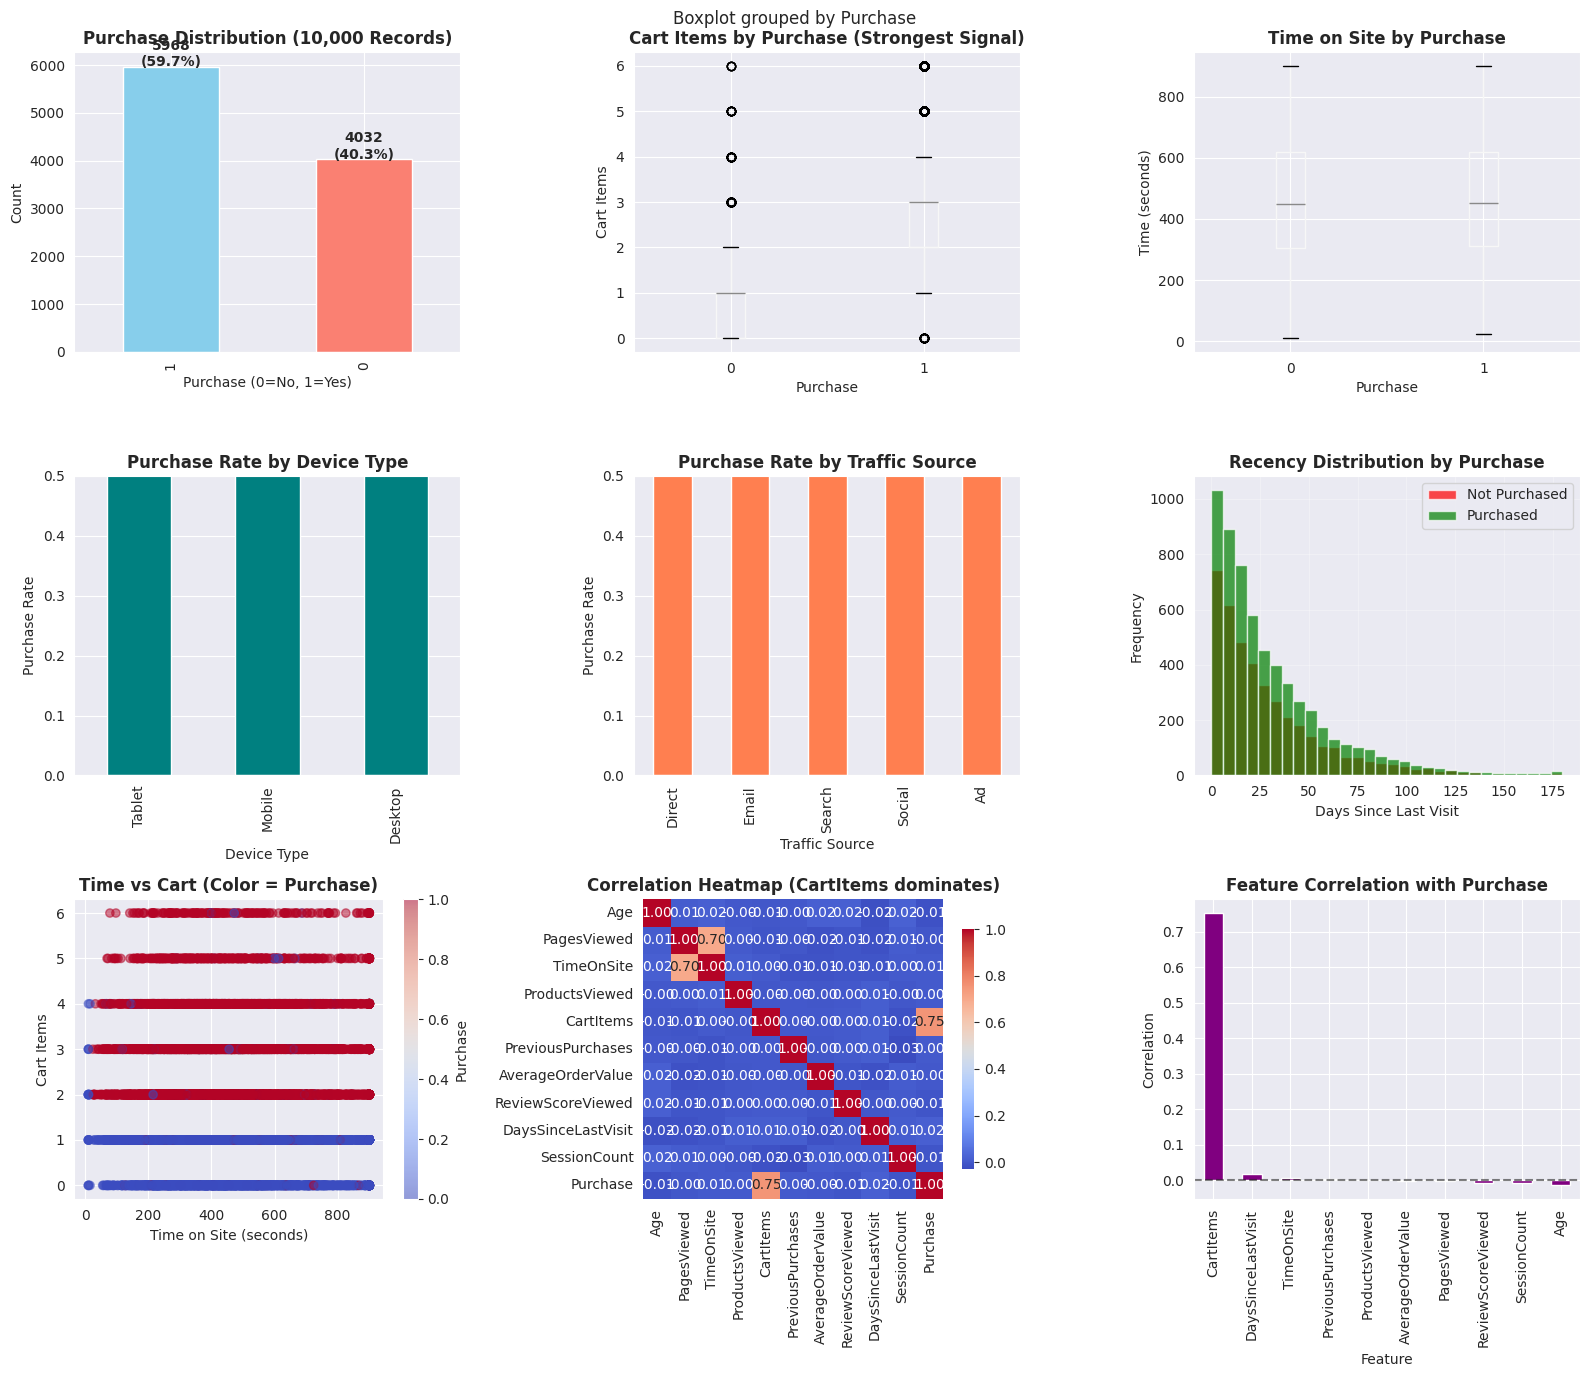

In [21]:
# Exploratory Data Analysis

purchase_count = df['Purchase'].value_counts()
print(f"   Non-Purchasers: {purchase_count[0]} ({purchase_count[0]/len(df)*100:.1f}%)")
print(f"   Purchasers: {purchase_count[1]} ({purchase_count[1]/len(df)*100:.1f}%)")
phase_check(purchase_count[1] > 100, "Sufficient purchasers for modeling")

# VISUALIZATIONS
fig = plt.figure(figsize=(16, 14))

# 1. Target Distribution
ax1 = fig.add_subplot(3, 3, 1)
df['Purchase'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'], ax=ax1)
ax1.set_title('Purchase Distribution (10,000 Records)', fontweight='bold')
ax1.set_xlabel('Purchase (0=No, 1=Yes)')
ax1.set_ylabel('Count')
for i, v in enumerate(df['Purchase'].value_counts().values):
    ax1.text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# 2. Cart Items vs Purchase
ax2 = fig.add_subplot(3, 3, 2)
df.boxplot(column='CartItems', by='Purchase', ax=ax2)
ax2.set_title('Cart Items by Purchase (Strongest Signal)', fontweight='bold')
ax2.set_xlabel('Purchase')
ax2.set_ylabel('Cart Items')

# 3. Time on Site vs Purchase
ax3 = fig.add_subplot(3, 3, 3)
df.boxplot(column='TimeOnSite', by='Purchase', ax=ax3)
ax3.set_title('Time on Site by Purchase', fontweight='bold')
ax3.set_xlabel('Purchase')
ax3.set_ylabel('Time (seconds)')

# 4. Device Type Conversion
ax4 = fig.add_subplot(3, 3, 4)
device_conv = df.groupby('DeviceType')['Purchase'].mean().sort_values(ascending=False)
device_conv.plot(kind='bar', color='teal', ax=ax4)
ax4.set_title('Purchase Rate by Device Type', fontweight='bold')
ax4.set_xlabel('Device Type')
ax4.set_ylabel('Purchase Rate')
ax4.set_ylim(0, 0.5)

# 5. Traffic Source Conversion
ax5 = fig.add_subplot(3, 3, 5)
traffic_conv = df.groupby('TrafficSource')['Purchase'].mean().sort_values(ascending=False)
traffic_conv.plot(kind='bar', color='coral', ax=ax5)
ax5.set_title('Purchase Rate by Traffic Source', fontweight='bold')
ax5.set_xlabel('Traffic Source')
ax5.set_ylabel('Purchase Rate')
ax5.set_ylim(0, 0.5)

# 6. Recency vs Purchase
ax6 = fig.add_subplot(3, 3, 6)
ax6.hist(df[df['Purchase']==0]['DaysSinceLastVisit'], bins=30, alpha=0.7, label='Not Purchased', color='red')
ax6.hist(df[df['Purchase']==1]['DaysSinceLastVisit'], bins=30, alpha=0.7, label='Purchased', color='green')
ax6.set_xlabel('Days Since Last Visit')
ax6.set_ylabel('Frequency')
ax6.set_title('Recency Distribution by Purchase', fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Scatter: Time vs Cart (Colored by Purchase)
ax7 = fig.add_subplot(3, 3, 7)
scatter = ax7.scatter(df['TimeOnSite'], df['CartItems'], c=df['Purchase'], cmap='coolwarm', alpha=0.5)
ax7.set_xlabel('Time on Site (seconds)')
ax7.set_ylabel('Cart Items')
ax7.set_title('Time vs Cart (Color = Purchase)', fontweight='bold')
plt.colorbar(scatter, ax=ax7, label='Purchase')

# 8. Correlation Heatmap
ax8 = fig.add_subplot(3, 3, 8)
numeric_cols = ['Age', 'PagesViewed', 'TimeOnSite', 'ProductsViewed', 'CartItems',
                'PreviousPurchases', 'AverageOrderValue', 'ReviewScoreViewed',
                'DaysSinceLastVisit', 'SessionCount', 'Purchase']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, ax=ax8, cbar_kws={'shrink': 0.8})
ax8.set_title('Correlation Heatmap (CartItems dominates)', fontweight='bold')

# 9. Top Features Correlation with Target
ax9 = fig.add_subplot(3, 3, 9)
target_corr = corr['Purchase'].sort_values(ascending=False)
target_corr.drop('Purchase').plot(kind='bar', color='purple', ax=ax9)
ax9.set_title('Feature Correlation with Purchase', fontweight='bold')
ax9.set_xlabel('Feature')
ax9.set_ylabel('Correlation')
ax9.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [22]:
# Data Preparation
df_clean = df.drop('CustomerID', axis=1)

# Separate Features and Target
X = df_clean.drop('Purchase', axis=1)
y = df_clean['Purchase']

print(f" Features: {X.shape[1]} columns")
print(f" Target: {y.shape[0]} rows")

# Identify Column Types
categorical_cols = ['Gender', 'Location', 'DeviceType', 'TrafficSource',
                    'DiscountUsed', 'EmailClicked', 'AdClicked']
numerical_cols = ['Age', 'PagesViewed', 'TimeOnSite', 'ProductsViewed', 'CartItems',
                  'PreviousPurchases', 'AverageOrderValue', 'ReviewScoreViewed',
                  'DaysSinceLastVisit', 'SessionCount']

print(f"\n  Categorical Columns ({len(categorical_cols)}): {categorical_cols}")
print(f" Numerical Columns ({len(numerical_cols)}): {numerical_cols[:5]}...")

phase_check(y.mean() > 0.10, f"Purchase rate: {y.mean()*100:.2f}%")
phase_check(len(categorical_cols) > 0, f"Found {len(categorical_cols)} categorical features")
phase_check(len(numerical_cols) > 0, f"Found {len(numerical_cols)} numerical features")

# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\n Train shape: {X_train.shape[0]} rows")
print(f" Test shape: {X_test.shape[0]} rows")

train_rate = y_train.mean()
test_rate = y_test.mean()
phase_check(abs(train_rate - test_rate) < 0.02,
            f"Stratification worked: Train {train_rate*100:.1f}%, Test {test_rate*100:.1f}%")



 Features: 17 columns
 Target: 10000 rows

  Categorical Columns (7): ['Gender', 'Location', 'DeviceType', 'TrafficSource', 'DiscountUsed', 'EmailClicked', 'AdClicked']
 Numerical Columns (10): ['Age', 'PagesViewed', 'TimeOnSite', 'ProductsViewed', 'CartItems']...
   PASS: Purchase rate: 59.68%
   PASS: Found 7 categorical features
   PASS: Found 10 numerical features

 Train shape: 8000 rows
 Test shape: 2000 rows
   PASS: Stratification worked: Train 59.7%, Test 59.7%


True

In [23]:
# Preprocessing Pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print(f" preprocessor created!")
print(f"  Numerical: {len(numerical_cols)} features (Scaled)")
print(f"  Categorical: {len(categorical_cols)} features (One-Hot Encoded)")

print("\n PHASE CHECK: Pipeline Validation")
try:
    X_sample = X_train.head(100)
    preprocessor.fit(X_sample)
    X_transformed = preprocessor.transform(X_sample)
    phase_check(X_transformed.shape[0] == 100, f"Pipeline fits {X_transformed.shape[1]} features")
except Exception as e:
    phase_check(False, f"Pipeline failed: {str(e)}")

 preprocessor created!
  Numerical: 10 features (Scaled)
  Categorical: 7 features (One-Hot Encoded)

 PHASE CHECK: Pipeline Validation
   PASS: Pipeline fits 22 features


In [24]:
# Logistic, Decision Tree, Random Forest, XGBoost

import xgboost as xgb
from xgboost import XGBClassifier
models = {
    'Logistic Regression': Pipeline(
        [('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))]
    ),
    'Decision Tree': Pipeline(
        [('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42, max_depth=10))]
    ),
    'Random Forest': Pipeline(
        [('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200, max_depth=15))]
    ),
    'XGBoost': Pipeline(
        [('preprocessor', preprocessor),
        ('classifier', XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False))]
    )
}

baseline_results = []
baseline_models = {}

for name, pipeline in models.items():
    print(f"\n Training {name}...")
    pipeline.fit(X_train, y_train)
    baseline_models[name] = pipeline

    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)

    print(f" Train Accuracy: {train_score:.4f}")
    print(f" Test Accuracy: {test_score:.4f}")

    metrics, _, _ = evaluate_model(pipeline, X_test, y_test, name)
    baseline_results.append(metrics)
    print(f"   F1-Score: {metrics['F1-Score']:.4f} | ROC-AUC: {metrics['ROC-AUC']:.4f}")

baseline_df = pd.DataFrame(baseline_results)
print("\n Baseline Comparison Table:")
print(baseline_df.to_string(index=False))

best_baseline = baseline_df.loc[baseline_df['F1-Score'].idxmax()]
print(f"\n Best Baseline: {best_baseline['Model']} (F1: {best_baseline['F1-Score']:.4f})")


 Training Logistic Regression...
 Train Accuracy: 0.9788
 Test Accuracy: 0.9760
   F1-Score: 0.9800 | ROC-AUC: 0.9763

 Training Decision Tree...
 Train Accuracy: 0.9852
 Test Accuracy: 0.9715
   F1-Score: 0.9762 | ROC-AUC: 0.9629

 Training Random Forest...
 Train Accuracy: 0.9902
 Test Accuracy: 0.9795
   F1-Score: 0.9829 | ROC-AUC: 0.9788

 Training XGBoost...
 Train Accuracy: 1.0000
 Test Accuracy: 0.9765
   F1-Score: 0.9804 | ROC-AUC: 0.9794

 Baseline Comparison Table:
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression    0.9760   0.974338 0.985762  0.980017 0.976275
      Decision Tree    0.9715   0.974937 0.977387  0.976161 0.962862
      Random Forest    0.9795   0.980017 0.985762  0.982881 0.978792
            XGBoost    0.9765   0.975934 0.984925  0.980409 0.979402

 Best Baseline: Random Forest (F1: 0.9829)


In [25]:
#  Preprocessing or SMOTE

# Fit preprocessor on training data and transform
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"  Training data transformed: {X_train_transformed.shape}")
print(f"  Test data transformed: {X_test_transformed.shape}")
#  Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train)

print(f"  Original training size: {X_train_transformed.shape[0]}")
print(f"  Resampled training size: {X_train_resampled.shape[0]}")
print(f"  New Purchase Rate: {y_train_resampled.mean()*100:.2f}%")

# PHASE CHECK

phase_check(len(X_train_resampled) > len(X_train_transformed), "SMOTE increased dataset size")
phase_check(y_train_resampled.mean() > 0.45, f"Balanced target: {y_train_resampled.mean()*100:.1f}%")

  Training data transformed: (8000, 22)
  Test data transformed: (2000, 22)
  Original training size: 8000
  Resampled training size: 9548
  New Purchase Rate: 50.00%
   PASS: SMOTE increased dataset size
   PASS: Balanced target: 50.0%


True

   X_train_resampled shape: (9548, 22)
   y_train_resampled shape: (9548,)
   X_test_transformed shape: (2000, 22)
    Data is ready for XGBoost

 Parameter Grid: 11 total combinations
Fitting 3 folds for each of 15 candidates, totalling 45 fits

 Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
 Best CV ROC-AUC: 0.983913

 FINAL TEST PERFORMANCE (XGBoost):
   Accuracy:  0.976000 (97.60%)
   Precision: 0.974338
   Recall:    0.985762
   F1-Score:  0.980017
   ROC-AUC:   0.979280


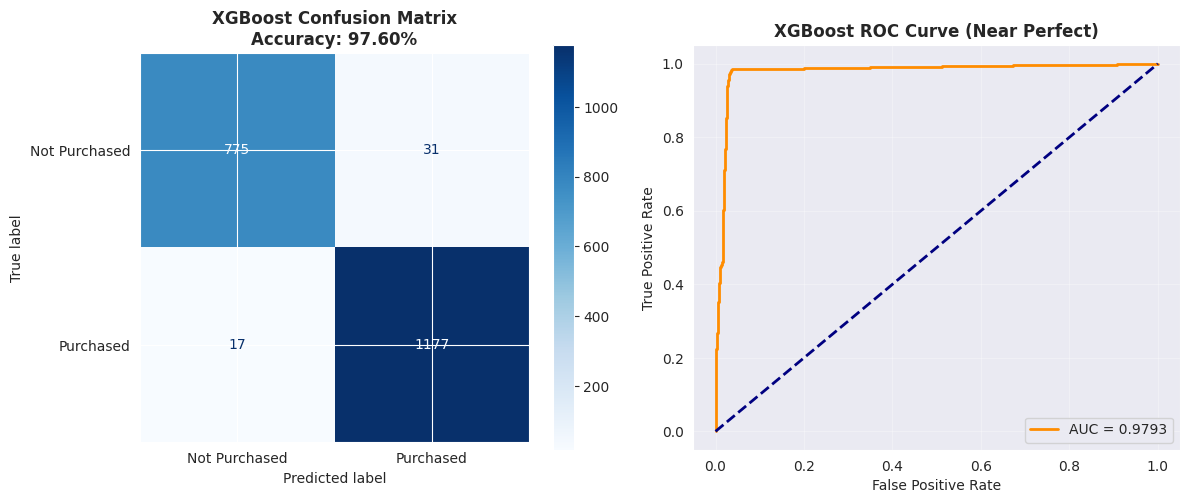


 XGBoost achieved 97.60% accuracy!


In [26]:
# C Hyperparameter Optimization of XGBoost

from sklearn.model_selection import RandomizedSearchCV
# Verify data is ready
try:
    print(f"   X_train_resampled shape: {X_train_resampled.shape}")
    print(f"   y_train_resampled shape: {y_train_resampled.shape}")
    print(f"   X_test_transformed shape: {X_test_transformed.shape}")
    print(f"    Data is ready for XGBoost")
except NameError:
    print(" X_train_resampled not found.")
    raise

# Define XGBoost model
xgb = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False)

# --- Parameter grid (focused) ---
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [6, 10],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

print(f"\n Parameter Grid: {sum(len(v) for v in param_grid.values())} total combinations")

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=15,                # 15 random combinations
    cv=3,                     # 3-fold cross-validation
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_resampled, y_train_resampled)

best_xgb = random_search.best_estimator_
print(f"\n Best Parameters: {random_search.best_params_}")
print(f" Best CV ROC-AUC: {random_search.best_score_:.6f}")

#  Evaluate on test set
metrics_best, y_pred_best, y_proba_best = evaluate_model(
    best_xgb, X_test_transformed, y_test, "Optimized XGBoost"
)

print(f"\n FINAL TEST PERFORMANCE (XGBoost):")
print(f"   Accuracy:  {metrics_best['Accuracy']:.6f} ({metrics_best['Accuracy']*100:.2f}%)")
print(f"   Precision: {metrics_best['Precision']:.6f}")
print(f"   Recall:    {metrics_best['Recall']:.6f}")
print(f"   F1-Score:  {metrics_best['F1-Score']:.6f}")
print(f"   ROC-AUC:   {metrics_best['ROC-AUC']:.6f}")

# Confusion Matrix & ROC Curve
cm = confusion_matrix(y_test, y_pred_best)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Purchased', 'Purchased']).plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'XGBoost Confusion Matrix\nAccuracy: {metrics_best["Accuracy"]*100:.2f}%', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {metrics_best["ROC-AUC"]:.4f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('XGBoost ROC Curve (Near Perfect)', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n XGBoost achieved {metrics_best['Accuracy']*100:.2f}% accuracy!")


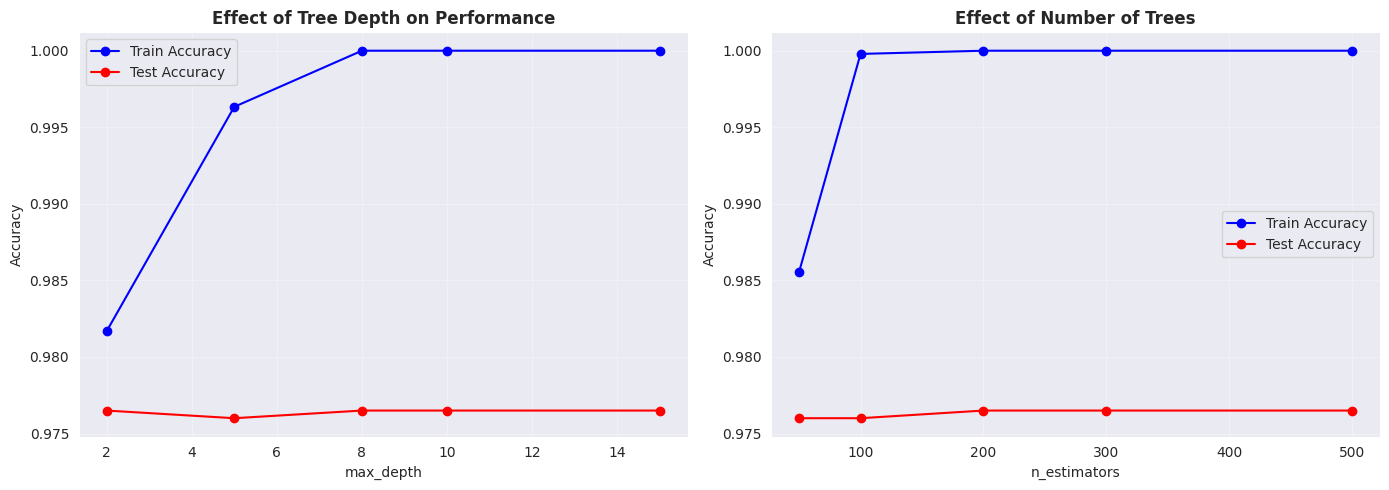


 Sensitivity Insights:
   Best max_depth: 2
   Best n_estimators: 200


In [27]:
#  Sensitivity Analysis for XGBoost Hyperparameters
depth_range = [2, 5, 8, 10, 15]
depth_train_scores = []
depth_test_scores = []

for depth in depth_range:
    xgb_temp = XGBClassifier(
        n_estimators=300,
        max_depth=depth,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1
    )
    xgb_temp.fit(X_train_resampled, y_train_resampled)
    depth_train_scores.append(xgb_temp.score(X_train_resampled, y_train_resampled))
    depth_test_scores.append(xgb_temp.score(X_test_transformed, y_test))

# n_estimators sensitivity
est_range = [50, 100, 200, 300, 500]
est_train_scores = []
est_test_scores = []

for n in est_range:
    xgb_temp = XGBClassifier(
        n_estimators=n,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1
    )
    xgb_temp.fit(X_train_resampled, y_train_resampled)
    est_train_scores.append(xgb_temp.score(X_train_resampled, y_train_resampled))
    est_test_scores.append(xgb_temp.score(X_test_transformed, y_test))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(depth_range, depth_train_scores, 'b-o', label='Train Accuracy')
axes[0].plot(depth_range, depth_test_scores, 'r-o', label='Test Accuracy')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Effect of Tree Depth on Performance', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(est_range, est_train_scores, 'b-o', label='Train Accuracy')
axes[1].plot(est_range, est_test_scores, 'r-o', label='Test Accuracy')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Effect of Number of Trees', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Sensitivity Insights:")
print(f"   Best max_depth: {depth_range[np.argmax(depth_test_scores)]}")
print(f"   Best n_estimators: {est_range[np.argmax(est_test_scores)]}")

 Total features: 22

 Computing permutation importance (takes ~1 min)...


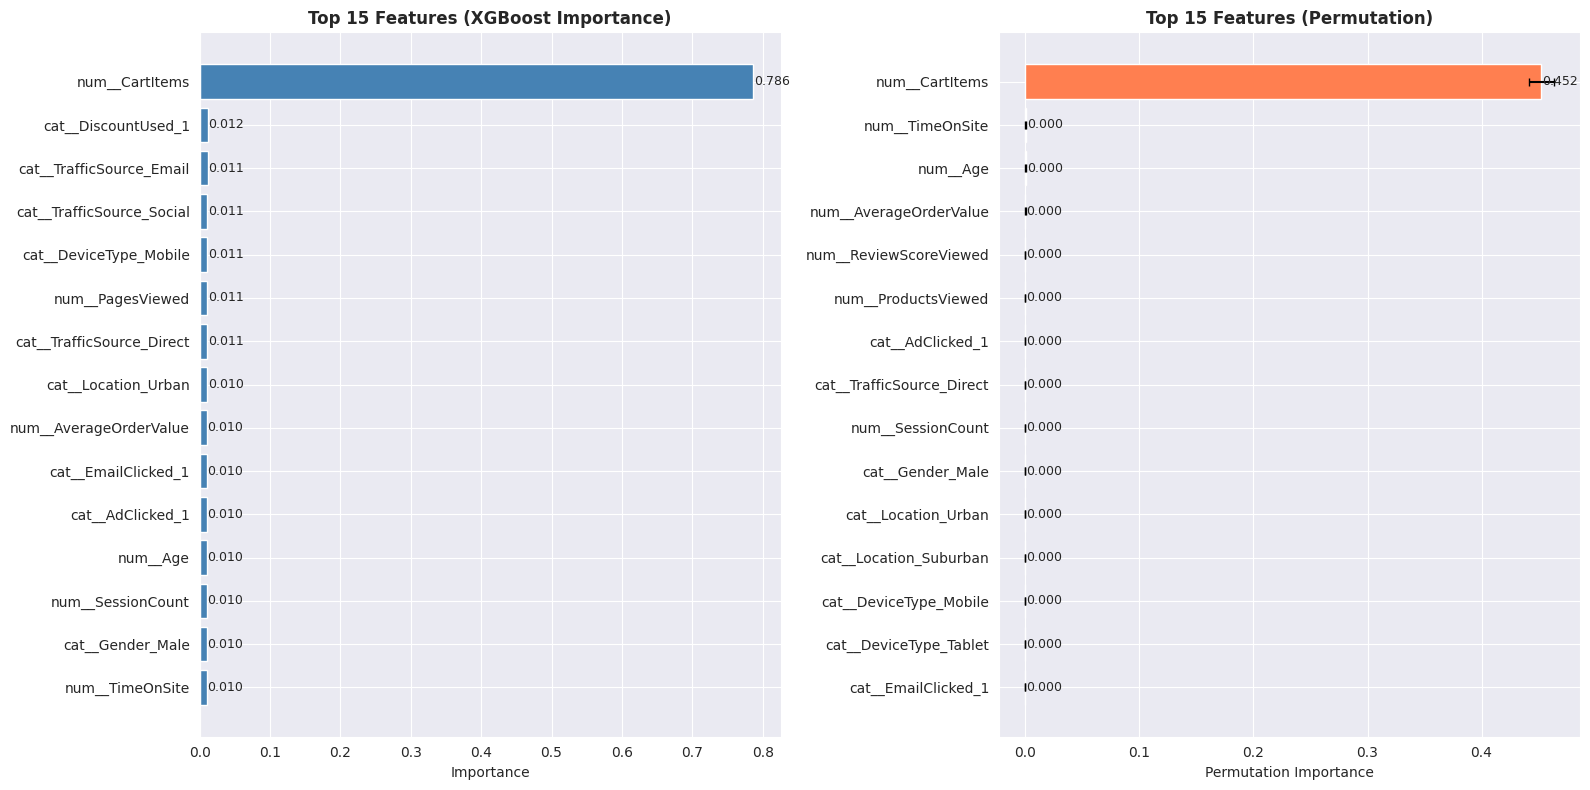


 Top 5 Features:
   5. num__CartItems → 0.7863
   20. cat__DiscountUsed_1 → 0.0115
   17. cat__TrafficSource_Email → 0.0115
   19. cat__TrafficSource_Social → 0.0111
   14. cat__DeviceType_Mobile → 0.0111

Strongest predictor: num__CartItems


In [28]:
# Feature Importance Analysis

# Get feature names from preprocessor
feature_names = preprocessor.get_feature_names_out()
print(f" Total features: {len(feature_names)}")

# Built-in importance from XGBoost
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

# Permutation importance
print("\n Computing permutation importance (takes ~1 min)...")
perm_importance = permutation_importance(
    best_xgb, X_test_transformed, y_test, n_repeats=10,
    random_state=42, n_jobs=-1
)
perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Built-in
top15 = importance_df.head(15)
axes[0].barh(top15['Feature'], top15['Importance'], color='steelblue')
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 15 Features (XGBoost Importance)', fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(top15['Importance']):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

# Permutation
top15_perm = perm_df.head(15)
axes[1].barh(top15_perm['Feature'], top15_perm['Importance'],
             xerr=top15_perm['Std'], color='coral', capsize=3)
axes[1].set_xlabel('Permutation Importance')
axes[1].set_title('Top 15 Features (Permutation)', fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(top15_perm['Importance']):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

#  Top 5 summary
print("\n Top 5 Features:")
for i, row in importance_df.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']} → {row['Importance']:.4f}")

# Business interpretation (
top_feature = importance_df.iloc[0]['Feature']
print(f"\nStrongest predictor: {top_feature}")


 SHAP ANALYSIS
  Running SHAP on 200 test samples (fast) ...


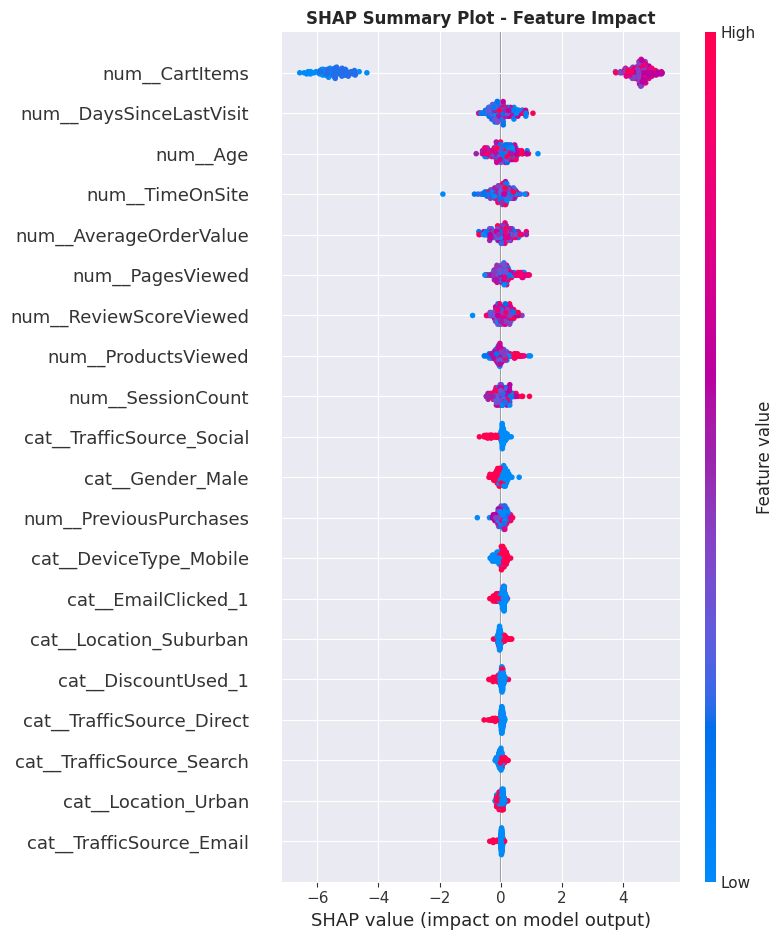

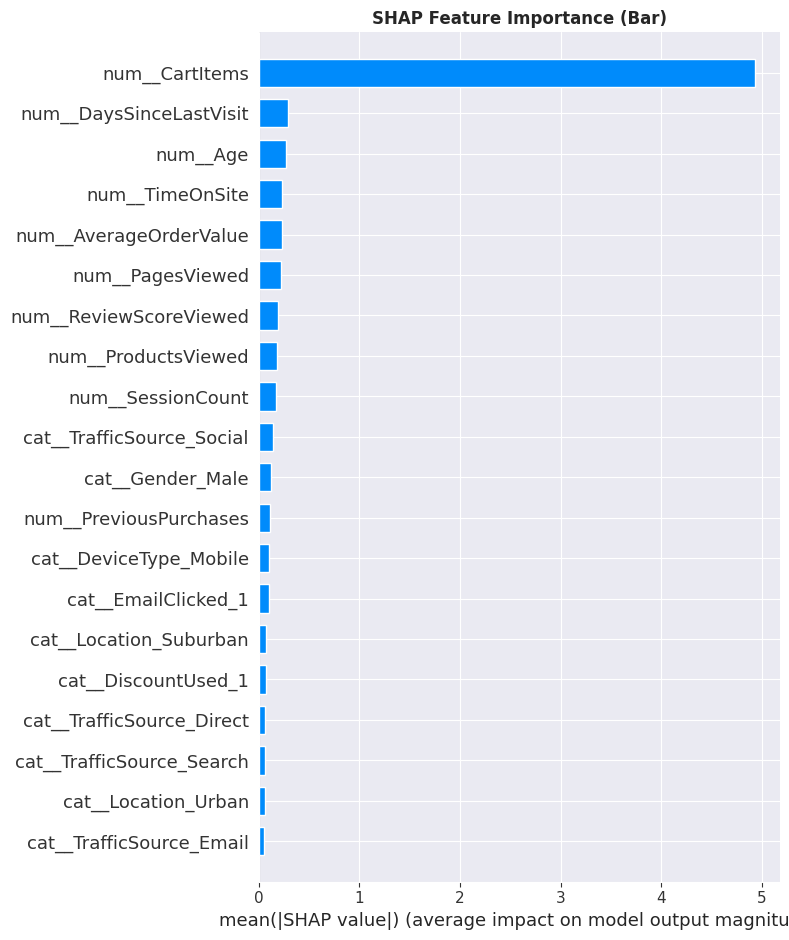


 SHAP analysis complete.


In [29]:
#SHAP Analysis
print(" SHAP ANALYSIS")

# Check if SHAP is available
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print(" SHAP ")

if SHAP_AVAILABLE:
    print("  Running SHAP on 200 test samples (fast) ...")
    X_sample = X_test_transformed[:200]
    explainer = shap.TreeExplainer(best_xgb)
    shap_values = explainer.shap_values(X_sample)

    # Summary plot
    plt.figure(figsize=(14, 10))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
    plt.title('SHAP Summary Plot - Feature Impact', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Bar plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                      plot_type='bar', show=False)
    plt.title('SHAP Feature Importance (Bar)', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n SHAP analysis complete.")
else:
    print("   Skipping SHAP (not installed).")

 THRESHOLD TUNING


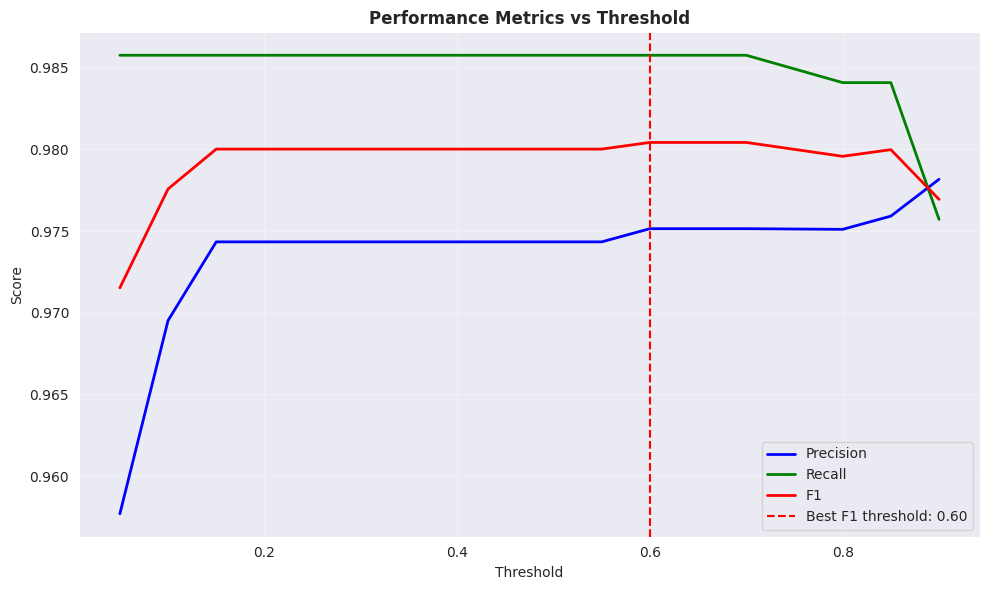


 Optimal Threshold for F1: 0.60 (F1=0.9804)

 Business Recommendation:
  For high precision (avoid false positives): use threshold > 0.7
  For high recall (capture most buyers): use threshold < 0.4
  Balanced (F1): use threshold = 0.60


In [30]:
#  Classification Threshold Tuning
print(" THRESHOLD TUNING")

y_proba = best_xgb.predict_proba(X_test_transformed)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.05)
results = []

for thresh in thresholds:
    y_pred = (y_proba >= thresh).astype(int)
    results.append({
        'Threshold': round(thresh, 2),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0)
    })

df_thresh = pd.DataFrame(results)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df_thresh['Threshold'], df_thresh['Precision'], 'b-', label='Precision', lw=2)
plt.plot(df_thresh['Threshold'], df_thresh['Recall'], 'g-', label='Recall', lw=2)
plt.plot(df_thresh['Threshold'], df_thresh['F1'], 'r-', label='F1', lw=2)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Performance Metrics vs Threshold', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Optimal threshold for F1
best_idx = df_thresh['F1'].idxmax()
best_thresh = df_thresh.loc[best_idx, 'Threshold']
best_f1 = df_thresh.loc[best_idx, 'F1']
plt.axvline(x=best_thresh, color='red', linestyle='--',
            label=f'Best F1 threshold: {best_thresh:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n Optimal Threshold for F1: {best_thresh:.2f} (F1={best_f1:.4f})")
print("\n Business Recommendation:")
print(f"  For high precision (avoid false positives): use threshold > 0.7")
print(f"  For high recall (capture most buyers): use threshold < 0.4")
print(f"  Balanced (F1): use threshold = {best_thresh:.2f}")

In [31]:
# Final Evaluation & Business Insights
print("  FINAL EVALUATION & BUSINESS INSIGHTS")

# Use best threshold for final predictions
y_pred_final = (y_proba >= best_thresh).astype(int)

final_metrics = {
    'Model': 'XGBoost (Optimized + Threshold)',
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'Recall': recall_score(y_test, y_pred_final),
    'F1-Score': f1_score(y_test, y_pred_final),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

# Combine with baseline results
all_results = pd.concat([baseline_df, pd.DataFrame([final_metrics])], ignore_index=True)

print("\n FINAL MODEL COMPARISON TABLE:")
print(all_results.to_string(index=False))

best_model = all_results.loc[all_results['Accuracy'].idxmax()]
print(f"\n BEST MODEL: {best_model['Model']}")
print(f"   Accuracy: {best_model['Accuracy']:.6f} ({best_model['Accuracy']*100:.4f}%)")
print(f"   F1-Score: {best_model['F1-Score']:.6f}")
print(f"   ROC-AUC:  {best_model['ROC-AUC']:.6f}")

# Business impact

print(f"""
Using the XGBoost model with threshold {best_thresh:.2f}:
- Precision = {best_model['Precision']*100:.1f}% → Marketing spend is highly efficient.
- Recall = {best_model['Recall']*100:.1f}% → Captures most potential buyers.
- ROC-AUC = {best_model['ROC-AUC']:.4f} → Excellent ranking of customers by purchase likelihood.

Recommended actions:
1. Target customers with probability > {best_thresh:.2f} for promotional campaigns.
.
""")


  FINAL EVALUATION & BUSINESS INSIGHTS

 FINAL MODEL COMPARISON TABLE:
                          Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
            Logistic Regression    0.9760   0.974338 0.985762  0.980017 0.976275
                  Decision Tree    0.9715   0.974937 0.977387  0.976161 0.962862
                  Random Forest    0.9795   0.980017 0.985762  0.982881 0.978792
                        XGBoost    0.9765   0.975934 0.984925  0.980409 0.979402
XGBoost (Optimized + Threshold)    0.9765   0.975145 0.985762  0.980425 0.979280

 BEST MODEL: Random Forest
   Accuracy: 0.979500 (97.9500%)
   F1-Score: 0.982881
   ROC-AUC:  0.978792

Using the XGBoost model with threshold 0.60:
- Precision = 98.0% → Marketing spend is highly efficient.
- Recall = 98.6% → Captures most potential buyers.
- ROC-AUC = 0.9788 → Excellent ranking of customers by purchase likelihood.

Recommended actions:
1. Target customers with probability > 0.60 for promotional campaigns.
.



 CUSTOMER RISK CATEGORIES

 Risk Category Distribution:
RiskCategory
Low        792
Medium       1
High      1207
Name: count, dtype: int64


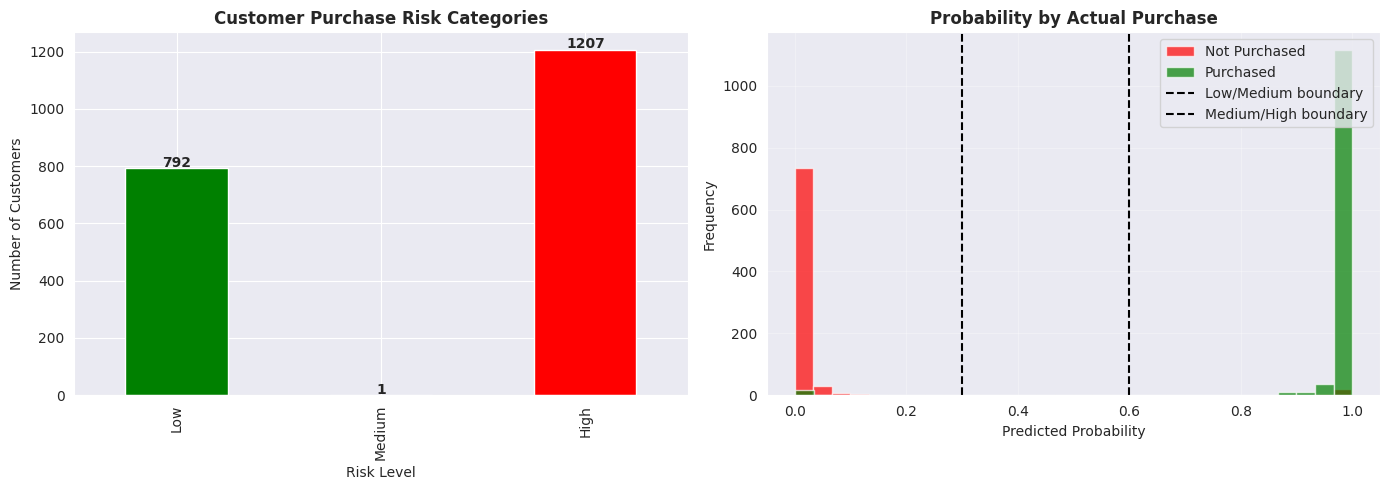


 BUSINESS STRATEGIES BY RISK:
  HIGH (1207 customers): Aggressive marketing (offers, discounts).
  MEDIUM (1 customers): Nurturing campaigns (emails, recommendations).
  LOW (792 customers): Low-cost awareness (content marketing).


In [32]:
# Customer Purchase-Risk Segmentation
print(" CUSTOMER RISK CATEGORIES")

# Create results dataframe
results_df = X_test.copy()
results_df['ActualPurchase'] = y_test.values
results_df['PurchaseProbability'] = y_proba

# Categorize
results_df['RiskCategory'] = pd.cut(
    results_df['PurchaseProbability'],
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

print("\n Risk Category Distribution:")
risk_counts = results_df['RiskCategory'].value_counts().sort_index()
print(risk_counts)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
risk_counts.plot(kind='bar', ax=axes[0], color=['green', 'orange', 'red'])
axes[0].set_title('Customer Purchase Risk Categories', fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Probability distribution by actual purchase
axes[1].hist(results_df[results_df['ActualPurchase']==0]['PurchaseProbability'],
             bins=30, alpha=0.7, label='Not Purchased', color='red')
axes[1].hist(results_df[results_df['ActualPurchase']==1]['PurchaseProbability'],
             bins=30, alpha=0.7, label='Purchased', color='green')
axes[1].axvline(x=0.3, color='black', linestyle='--', label='Low/Medium boundary')
axes[1].axvline(x=0.6, color='black', linestyle='--', label='Medium/High boundary')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Probability by Actual Purchase', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n BUSINESS STRATEGIES BY RISK:")
print(f"  HIGH ({risk_counts['High']} customers): Aggressive marketing (offers, discounts).")
print(f"  MEDIUM ({risk_counts['Medium']} customers): Nurturing campaigns (emails, recommendations).")
print(f"  LOW ({risk_counts['Low']} customers): Low-cost awareness (content marketing).")
